In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

In [3]:
x = np.array([[1, 0], [0, 1], [1 ,1]])
y = np.array([1, 5, 2])

# a 

In [4]:
psi = x
F = psi.T @ psi

a, b = (np.linalg.inv(F) @ psi.T @ y).ravel()

print (f'Уравнение линейной регрессии: w = {np.round(a, 3)} * x + {np.round(b, 3)} * y')

Уравнение линейной регрессии: w = -0.333 * x + 3.667 * y


# b

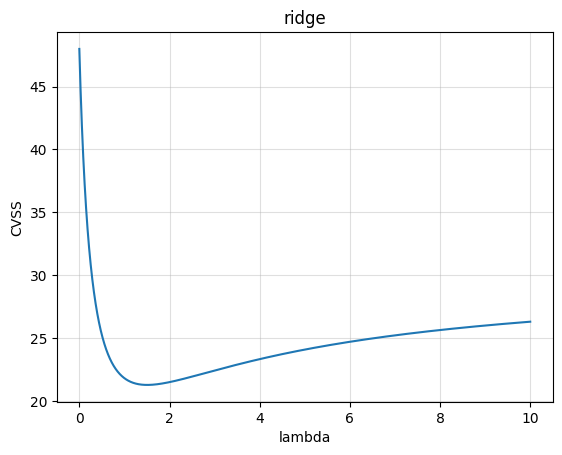

In [5]:
best_lamd = 0
lambd = np.linspace(0, 10, 10000)
CVSS_data = []

for i in range (len(lambd)):
    CVSS = 0
    for j in range (3):
        mask = np.array([True] * j + [False] + [True] * (2 - j))
        x_i = x[mask]
        y_i = y[mask]

        psi_new = x_i

        A = psi_new.T @ psi_new + lambd[i] * np.eye(psi_new.shape[1])
        b = np.linalg.solve(A, psi_new.T @ y_i.reshape(-1, 1))

        psi_test = x[j]

        CVSS_i = (y[j] - psi_test @ b) ** 2
        CVSS += CVSS_i
    CVSS_data.append(CVSS)

CVSS_data = np.array(CVSS_data).flatten()
plt.plot(lambd, CVSS_data)
plt.title('ridge')
plt.ylabel('CVSS')
plt.xlabel('lambda')
plt.grid(alpha = 0.4)
plt.show()

In [6]:
optimal_index = np.argmin(CVSS_data)
print (f'параметр регуляризации = {np.round(lambd[optimal_index], 3)}')

A = psi.T @ psi + lambd[optimal_index] * np.eye(psi.shape[1])
coeff_ridge = np.linalg.solve(A, psi.T @ y.reshape(-1, 1)).reshape(1, 2)

a_ridge = coeff_ridge[0, 0]
b_ridge = coeff_ridge[0, 1]

print (f'Уравнение ridge регрессии: w = {np.round(a_ridge, 3)} * x + {np.round(b_ridge, 3)} * y')

параметр регуляризации = 1.506
Уравнение ridge регрессии: w = 0.312 * x + 1.908 * y


# c

параметр регуляризации = 6.0
Уравнение lasso регрессии: w = 0.0 * x + 2.0 * y


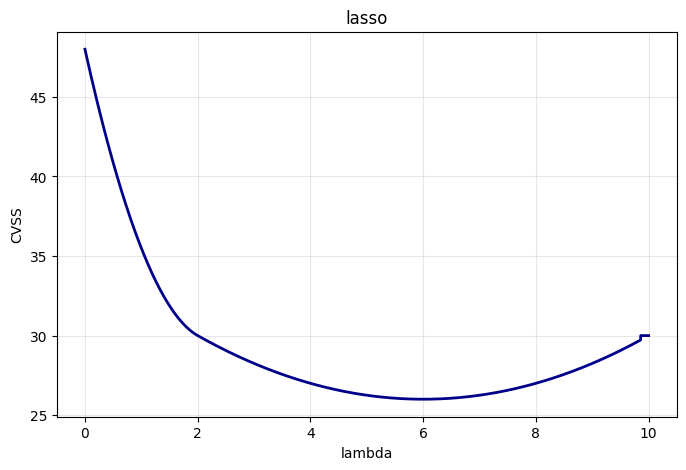

In [ ]:
lambdas = np.linspace(0, 10, 10000)
N = 3
n = 3

def lasso_fit(psi_train, y_train, alpha_lec):
    n_loc = psi_train.shape[0]
    if alpha_lec == 0:
        return np.linalg.solve(psi_train.T @ psi_train, psi_train.T @ y_train)
    alpha_sk = alpha_lec / (2 * n_lo c)
    model = Lasso(alpha=alpha_sk, fit_intercept=False, max_iter=100000)
    model.fit(psi_train, y_train)
    return model.coef_

CVSS_lasso = []
for k, alpha in enumerate(lambdas):
    cvss = 0.0
    for i in range(n):
        psi_train = np.delete(psi, i, axis=0)
        y_train = np.delete(y, i)
        beta_loo = lasso_fit(psi_train, y_train, alpha)
        y_pred = psi[i] @ beta_loo
        cvss += (y[i] - y_pred) ** 2
    CVSS_lasso.append(cvss)

CVSS_lasso = np.array(CVSS_lasso)

alpha_opt_lasso = lambdas[np.argmin(CVSS_lasso)]
beta_opt_lasso = lasso_fit(psi, y, alpha_opt_lasso)

print(f'параметр регуляризации = {np.round(alpha_opt_lasso, 3)}')
print(f'Уравнение lasso регрессии: w = {np.round(beta_opt_lasso[0], 3)} * x + {np.round(beta_opt_lasso[1], 3)} * y')

plt.figure(figsize=(8, 5))
plt.plot(lambdas, CVSS_lasso, color='darkblue', linewidth=2)
plt.xlabel('lambda')
plt.ylabel('CVSS')
plt.title('lasso')
plt.grid(True, alpha=0.3)
plt.show()